In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("housing.csv")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.shape

(20640, 10)

In [7]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [9]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [10]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

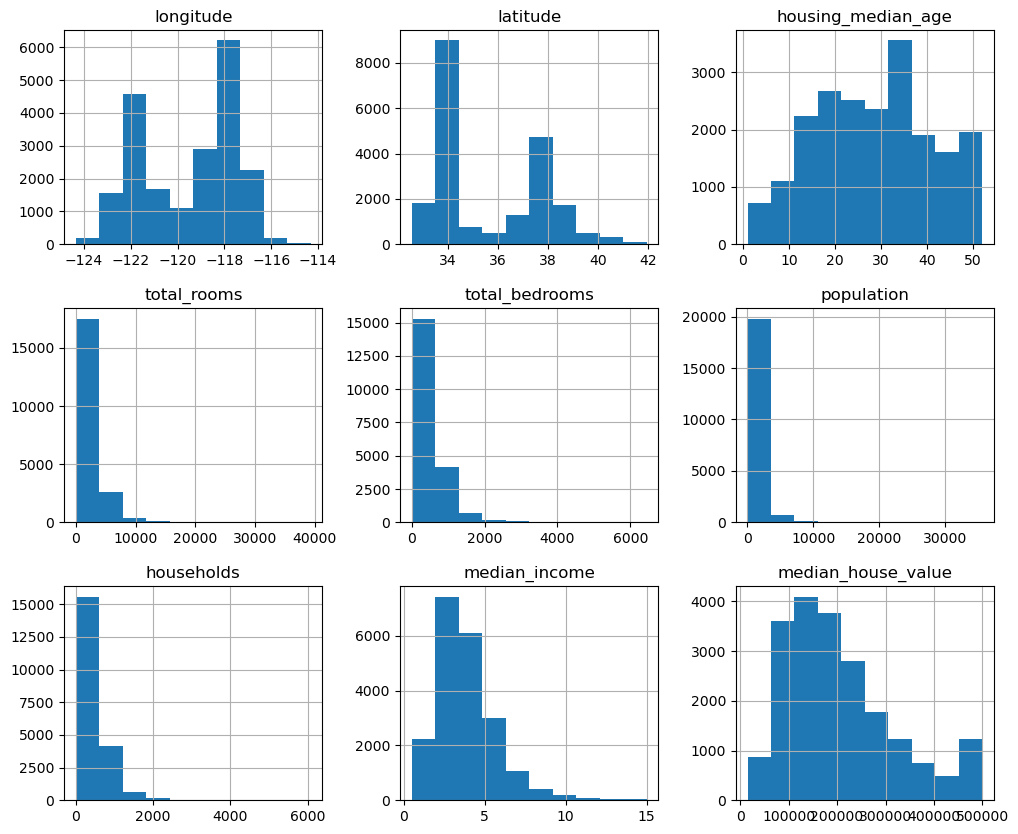

In [11]:
df.hist(figsize=(12,10))
plt.show()

In [12]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].mean())

In [13]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [14]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [16]:
df["ocean_proximity"].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [17]:
df = pd.get_dummies(df, columns=["ocean_proximity"])

In [18]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


In [19]:
X = df.drop("median_house_value", axis=1)

y = df["median_house_value"]

In [20]:
print(X.shape)
print(y.shape)

(20640, 13)
(20640,)


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16512, 13)
X_test shape: (4128, 13)
y_train shape: (16512,)
y_test shape: (4128,)


In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [25]:
print(X_train[:5])

[[ 1.27258656 -1.3728112   0.34849025  0.22256942  0.21122752  0.76827628
   0.32290591 -0.326196   -0.89468316 -0.68057418 -0.01556621 -0.35564565
   2.62975816]
 [ 0.70916212 -0.87669601  1.61811813  0.34029326  0.59309419 -0.09890135
   0.6720272  -0.03584338 -0.89468316 -0.68057418 -0.01556621 -0.35564565
   2.62975816]
 [-0.44760309 -0.46014647 -1.95271028 -0.34259695 -0.49522582 -0.44981806
  -0.43046109  0.14470145 -0.89468316 -0.68057418 -0.01556621 -0.35564565
   2.62975816]
 [ 1.23269811 -1.38217186  0.58654547 -0.56148971 -0.40930582 -0.00743434
  -0.38058662 -1.01786438 -0.89468316 -0.68057418 -0.01556621 -0.35564565
   2.62975816]
 [-0.10855122  0.5320839   1.14200767 -0.11956547 -0.25655915 -0.48587717
  -0.31496232 -0.17148831 -0.89468316  1.46934754 -0.01556621 -0.35564565
  -0.3802631 ]]


In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
model = LinearRegression()

In [28]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
predictions = model.predict(X_test)

In [30]:
print("Predicted Values:\n")
print(predictions[:10])

Predicted Values:

[ 64629.45079786 134799.34083607 266063.38139054 278576.43346807
 273343.43671457 150180.30585448 301239.42581305 238838.87827418
 267080.78750893 418497.86033374]


In [31]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
0,47700.0,64629.450798
1,45800.0,134799.340836
2,500001.0,266063.381391
3,218600.0,278576.433468
4,278000.0,273343.436715
5,158700.0,150180.305854
6,198200.0,301239.425813
7,157500.0,238838.878274
8,340000.0,267080.787509
9,446600.0,418497.860334


In [32]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [33]:
mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 50701.77903132993


In [34]:
mse = mean_squared_error(y_test, predictions)

print("MSE:", mse)

MSE: 4904399775.949276


In [35]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 70031.41991955665


In [36]:
r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

R2 Score: 0.6257351821159705


In [37]:
import matplotlib.pyplot as plt

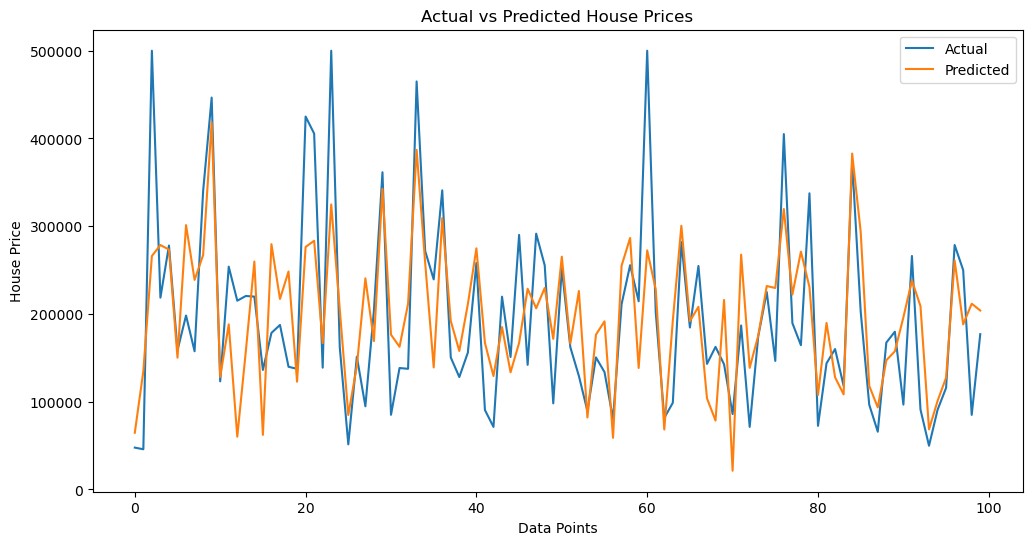

In [38]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label='Actual')
plt.plot(predictions[:100], label='Predicted')

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Data Points")
plt.ylabel("House Price")

plt.legend()

plt.show()

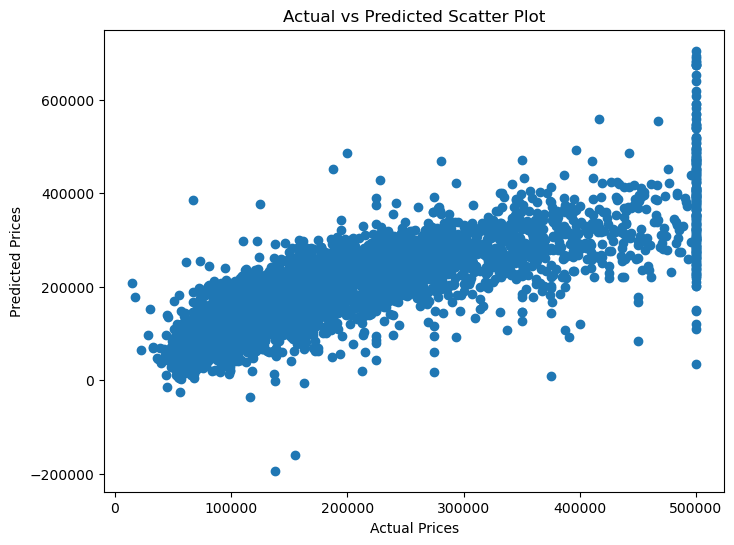

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Scatter Plot")

plt.show()

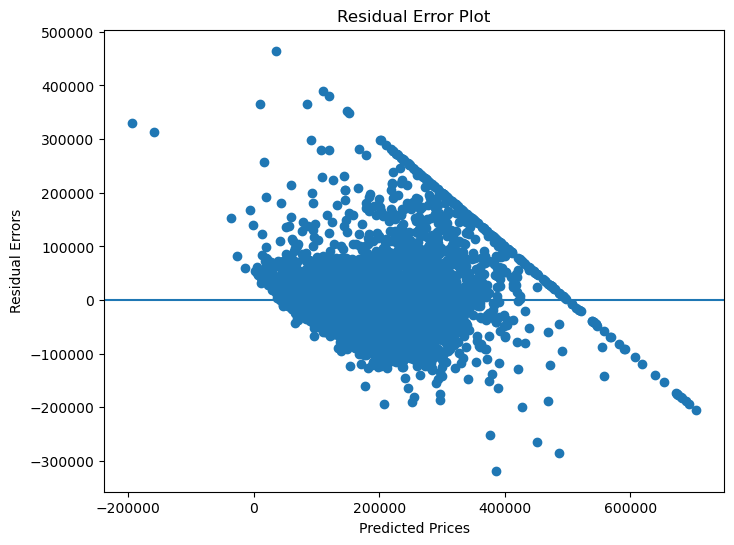

In [40]:
residuals = y_test - predictions

plt.figure(figsize=(8,6))

plt.scatter(predictions, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Prices")
plt.ylabel("Residual Errors")

plt.title("Residual Error Plot")

plt.show()

In [41]:
from sklearn.ensemble import RandomForestRegressor

In [42]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [43]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
rf_predictions = rf_model.predict(X_test)

In [45]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [46]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_mse = mean_squared_error(y_test, rf_predictions)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("----------------------")

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
----------------------
MAE: 31659.441540697677
RMSE: 48925.828359854
R2 Score: 0.8173290384570426


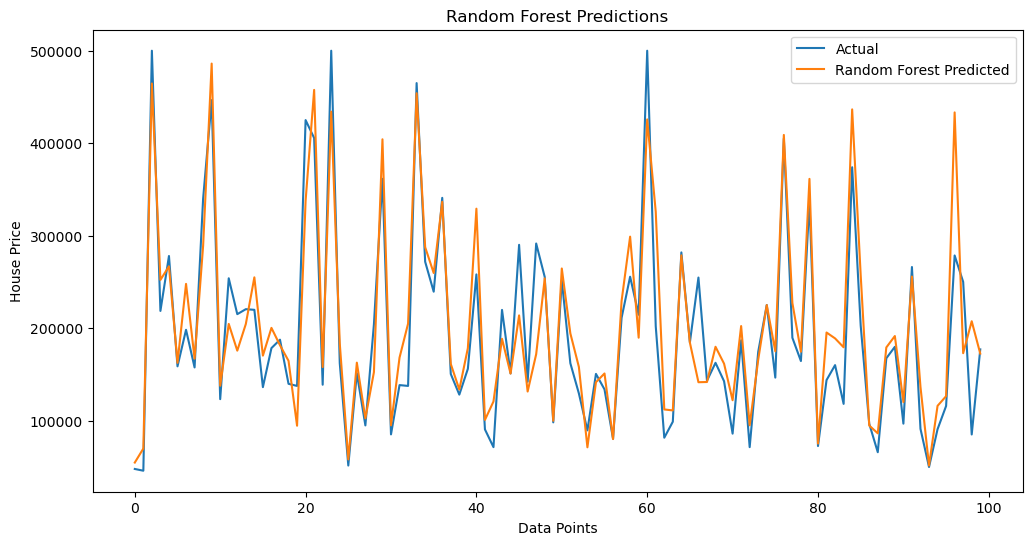

In [47]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label='Actual')
plt.plot(rf_predictions[:100], label='Random Forest Predicted')

plt.title("Random Forest Predictions")

plt.xlabel("Data Points")
plt.ylabel("House Price")

plt.legend()

plt.show()

In [48]:
importance = rf_model.feature_importances_

In [49]:
feature_names = X.columns

In [50]:
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

In [51]:
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

In [52]:
feature_importance_df.head(10)

,Feature,Importance
7,median_income,0.490642
9,ocean_proximity_INLAND,0.140925
0,longitude,0.105889
1,latitude,0.101597
2,housing_median_age,0.051935
5,population,0.032573
4,total_bedrooms,0.023819
3,total_rooms,0.023366
6,households,0.018367
12,ocean_proximity_NEAR OCEAN,0.006336


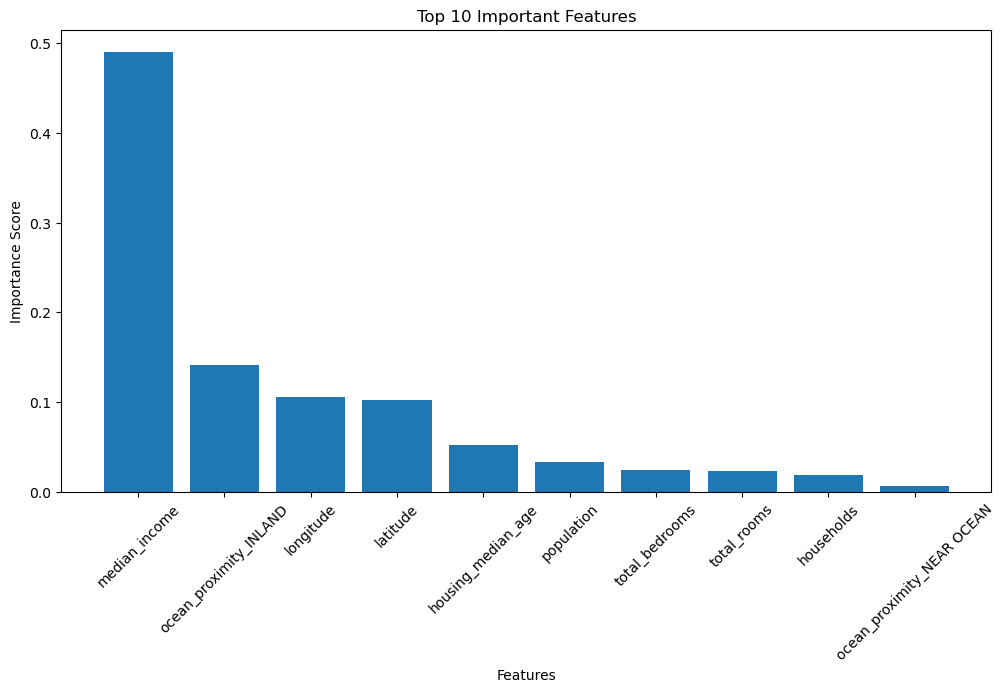

In [53]:
plt.figure(figsize=(12,6))

plt.bar(
    feature_importance_df['Feature'][:10],
    feature_importance_df['Importance'][:10]
)

plt.xticks(rotation=45)

plt.title("Top 10 Important Features")

plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()

In [55]:
import joblib

In [56]:
joblib.dump(rf_model, "house_price_model.pkl")

['house_price_model.pkl']

In [57]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [58]:
loaded_model = joblib.load("house_price_model.pkl")

In [59]:
sample_prediction = loaded_model.predict(X_test[:5])

print(sample_prediction)

[ 54628.    69786.   464580.37 252145.   266818.  ]
